In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import h5py

In [3]:
mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\100Mbps\air\ethernet_packets_1000_5cm.mat'
air_exposed_mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\100Mbps\air\ethernet_packets_1000_5cm.mat'
water_exposed_mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\100Mbps\water\ethernet_packets_1000_5cm.mat'

In [4]:
with h5py.File(mat_file, 'r') as f:
    reference_packet = np.array(f['packets'])  # shape: (recordLength,)
    # Access metadata
    metadata = f['metadata']
    sample_rate = metadata['sample_rate'][0][0]
    trigger_level = metadata['trigger_level'][0][0]
    record_length = metadata['record_length'][0][0]
    num_frames = metadata['num_frames'][0][0]

In [5]:
with h5py.File(air_exposed_mat_file, 'r') as f:
    reference_packet_air = np.array(f['packets'])  # shape: (recordLength,)
    # Access metadata
    metadata = f['metadata']
    sample_rate = metadata['sample_rate'][0][0]
    trigger_level = metadata['trigger_level'][0][0]
    record_length = metadata['record_length'][0][0]
    num_frames = metadata['num_frames'][0][0]

In [6]:
with h5py.File(water_exposed_mat_file, 'r') as f:
    reference_packet_water = np.array(f['packets'])  # shape: (recordLength,)
    # Access metadata
    metadata = f['metadata']
    sample_rate = metadata['sample_rate'][0][0]
    trigger_level = metadata['trigger_level'][0][0]
    record_length = metadata['record_length'][0][0]
    num_frames = metadata['num_frames'][0][0]

In [7]:
reference_packet = reference_packet[5,:]
reference_packet_air = reference_packet_air[4,:]
reference_packet_water = reference_packet_water[4,:]

In [8]:
reference_packet_air

array([ 0.49828125,  0.48265625,  0.5203125 , ..., -0.01414063,
       -0.01460938, -0.0025    ], shape=(250000,))

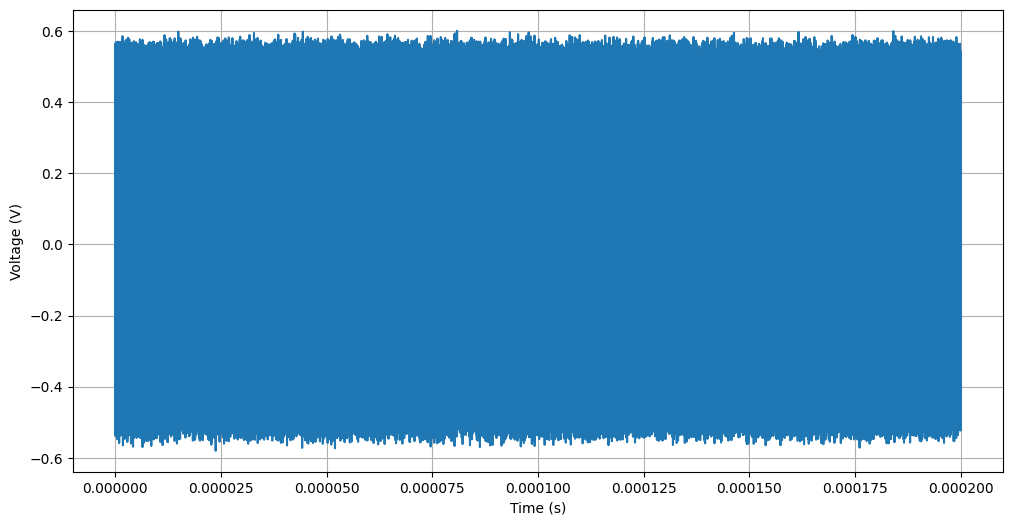

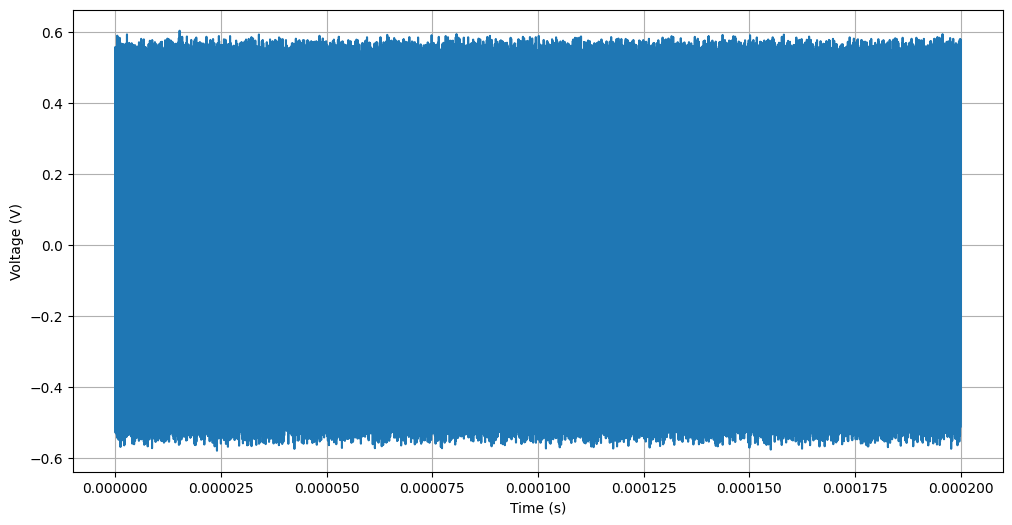

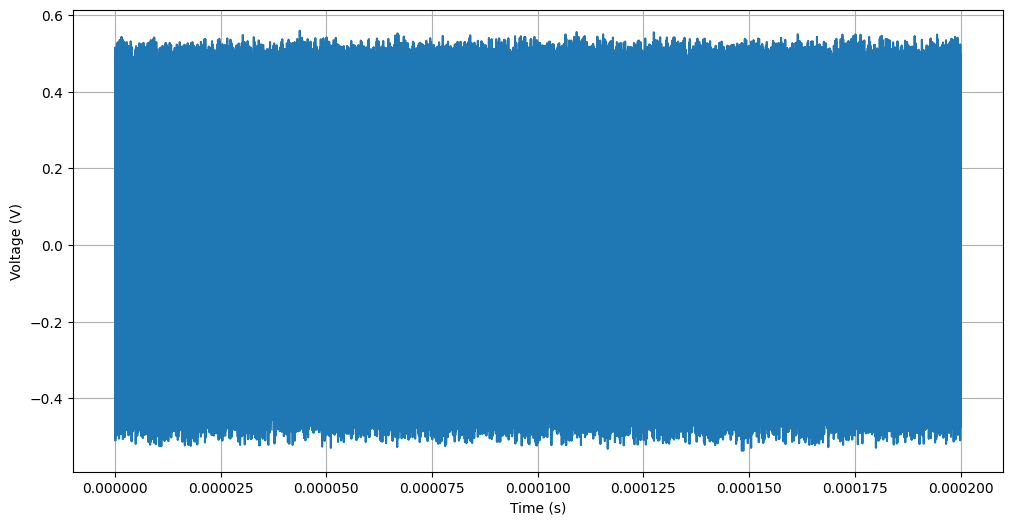

In [9]:
time_axis = np.arange(record_length) / sample_rate
for packet in reference_packet,reference_packet_air, reference_packet_water:
    plt.figure(figsize=(12,6))
    plt.plot(time_axis, packet, label='Packet')  # Plot each packet
    # plt.title(f'Reference Ethernet Packet')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (V)')
    plt.grid(True)
    plt.show()

In [10]:
def extract_signal_region(signal, threshold=0.1):
    """Trims the quiet parts of the signal before and after the packet."""
    active = np.abs(signal) > threshold
    indices = np.where(active)[0]
    if indices.size == 0:
        return np.array([])
    return signal[indices[0] : indices[-1] + 1]

In [11]:
# reference_packet = extract_signal_region(reference_packet, threshold=0.1)
# reference_packet_air = extract_signal_region(reference_packet_air, threshold=0.2)
# reference_packet_water = extract_signal_region(reference_packet_water, threshold=0.2)

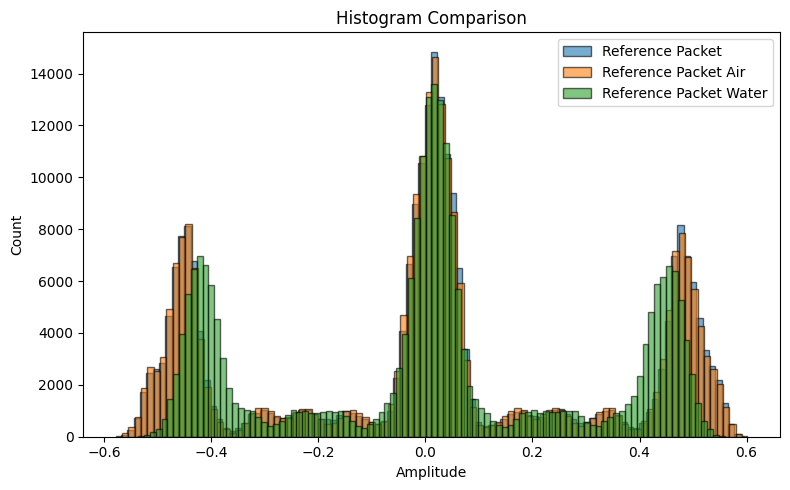

In [12]:
import matplotlib.pyplot as plt

# Data setup
packets = [reference_packet, reference_packet_air, reference_packet_water]
labels = ["Reference Packet", "Reference Packet Air", "Reference Packet Water"]

plt.figure(figsize=(8, 5))

# Plot both histograms on the same axes
plt.hist(reference_packet, bins=100, alpha=0.6, label="Reference Packet", edgecolor='black')
plt.hist(reference_packet_air, bins=100, alpha=0.6, label="Reference Packet Air", edgecolor='black')
plt.hist(reference_packet_water, bins=100, alpha=0.6, label="Reference Packet Water", edgecolor='black')

plt.title("Histogram Comparison")
plt.xlabel("Amplitude")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\NITRO 5\AppData\Local\Temp\ipykernel_19812\1969987225.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


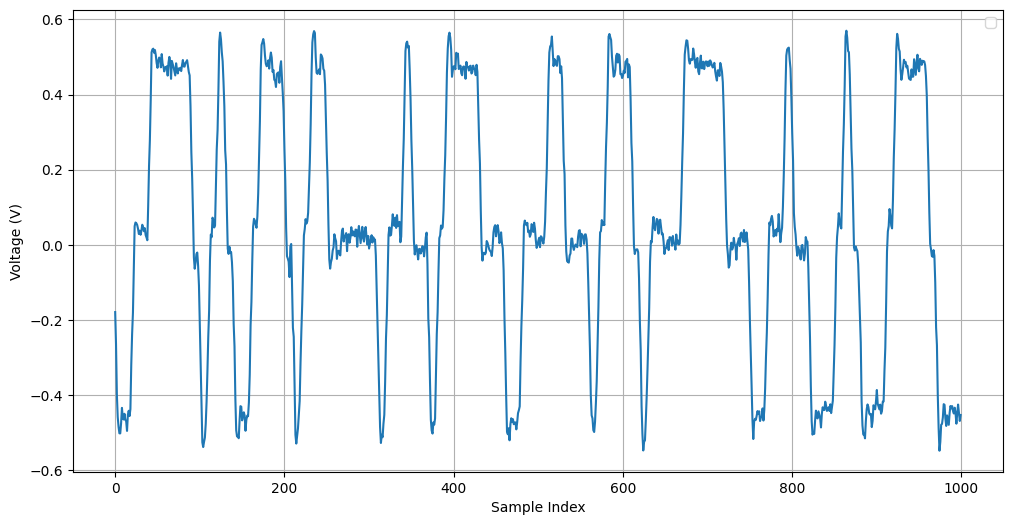

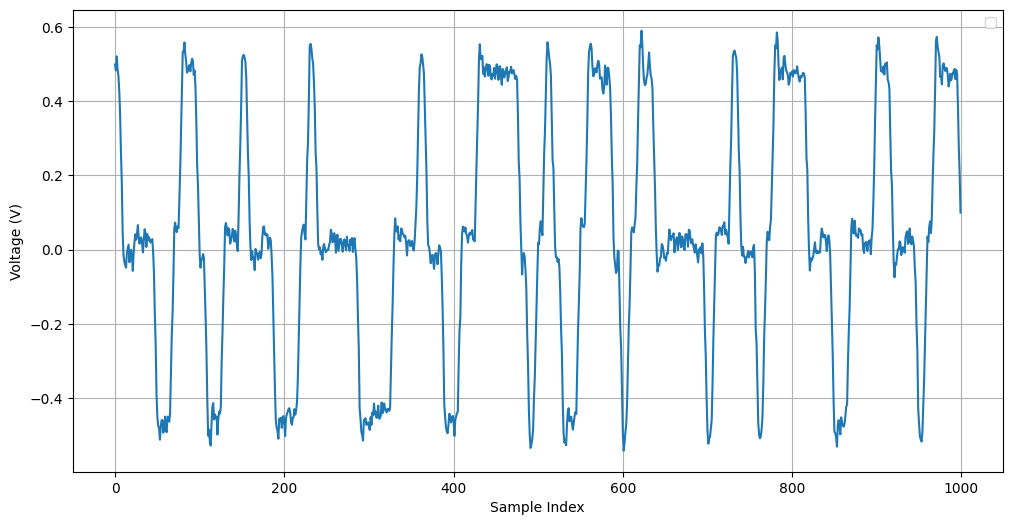

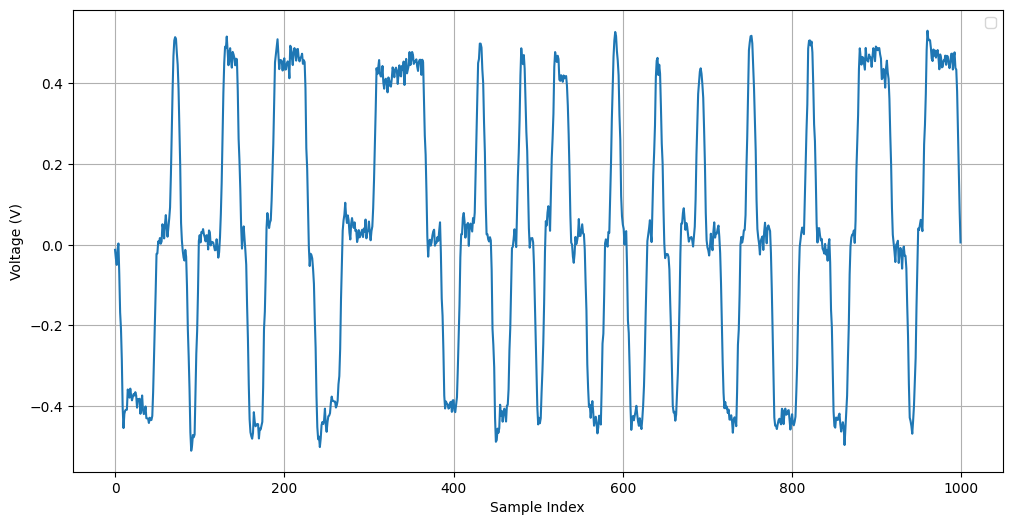

In [14]:
# plot the first 10000 samples of each packet seperately  in the same plot
for packet, label in zip(packets, labels):
    plt.figure(figsize=(12,6))
    plt.plot(packet[:1000])  # Plot each packet
    plt.xlabel('Sample Index')
    plt.ylabel('Voltage (V)')
    plt.grid(True)
    plt.legend()
    plt.show()